In [3]:
import subprocess
subprocess.run(["pip", "install", "-q",
    "faiss-cpu", "pymupdf", "python-pptx",
    "langchain-text-splitters", "sentence-transformers",
    "transformers", "accelerate", "bitsandbytes",
    "fastapi", "uvicorn", "pyngrok", "nest-asyncio",
    "rank-bm25", "bert-score", "rouge-score",
    "scikit-learn", "scipy", "matplotlib", "pandas"])
print("✅ Libraries installed")

✅ Libraries installed


In [4]:
import gc, os, json, random, time
import torch
import torch.nn as nn
import faiss
import pickle
import numpy as np
import pandas as pd
from collections import Counter
from google.colab import drive
from sentence_transformers import SentenceTransformer
from transformers import (AutoTokenizer, AutoModelForCausalLM,
                          BitsAndBytesConfig, AutoConfig)
from rank_bm25 import BM25Okapi
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import (f1_score, classification_report,
                              confusion_matrix, ConfusionMatrixDisplay,
                              roc_curve, auc, precision_recall_curve)
from sklearn.preprocessing import label_binarize
from scipy import stats
import matplotlib.pyplot as plt

drive.mount('/content/drive', force_remount=True)
print("✅ Drive mounted")

Mounted at /content/drive
✅ Drive mounted


In [5]:
class IntentClassifier(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_classes):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(hidden_dim, hidden_dim // 2), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(hidden_dim // 2, num_classes)
        )
    def forward(self, x):
        return self.net(x)

def set_seeds(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

num_classes = 5
class_names = ['Definition', 'Explanation', 'Identification',
               'Procedural', 'Out-of-scope']
print("✅ IntentClassifier and helpers ready")

✅ IntentClassifier and helpers ready


In [6]:
print("Loading BGE-M3...")
embedder = SentenceTransformer('BAAI/bge-m3')
print("✅ BGE-M3 ready")

print("Loading FAISS index...")
index = faiss.read_index('/content/drive/MyDrive/Nyansapo/nyansapo_v2.index')
with open('/content/drive/MyDrive/Nyansapo/chunks_v2.pkl', 'rb') as f:
    all_chunks = pickle.load(f)
print(f"✅ FAISS index loaded — {index.ntotal} chunks")

print("Loading BM25 index...")
with open('/content/drive/MyDrive/Nyansapo/bm25_v2.pkl', 'rb') as f:
    bm25 = pickle.load(f)
print("✅ BM25 loaded")

Loading BGE-M3...


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/123 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/15.8k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/54.0 [00:00<?, ?B/s]

...

tokenizer.json: reconstructing file:   0%|          |  0.00B / 17.1MB            

tokenizer.json: downloading bytes:           |  0.00B            

special_tokens_map.json:   0%|          | 0.00/964 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/191 [00:00<?, ?B/s]

✅ BGE-M3 ready
Loading FAISS index...
✅ FAISS index loaded — 12311 chunks
Loading BM25 index...
✅ BM25 loaded


In [7]:
torch.cuda.empty_cache()
gc.collect()
print("Loading Phi-2 (5-10 mins)...")

model_name = "microsoft/phi-2"
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True, bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16
)
tokenizer = AutoTokenizer.from_pretrained(model_name, trust_remote_code=True)
tokenizer.pad_token = tokenizer.eos_token

config = AutoConfig.from_pretrained(model_name, trust_remote_code=True)
config.pad_token_id = tokenizer.eos_token_id

model = AutoModelForCausalLM.from_pretrained(
    model_name, config=config, quantization_config=bnb_config,
    device_map="auto", trust_remote_code=True, torch_dtype=torch.float16)
print("✅ Phi-2 loaded")

Loading Phi-2 (5-10 mins)...


config.json:   0%|          | 0.00/735 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/7.34k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/798k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

...

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/453 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

✅ Phi-2 loaded


In [30]:
def retrieve(query, k=5):
    query_vec = embedder.encode([query], normalize_embeddings=True)
    query_vec = np.array(query_vec).astype('float32')
    _, dense_indices = index.search(query_vec, k*2)
    bm25_scores  = bm25.get_scores(query.lower().split())
    bm25_indices = np.argsort(bm25_scores)[::-1][:k*2]
    rrf_scores = {}
    for rank, idx in enumerate(dense_indices[0]):
        if idx < len(all_chunks):
            rrf_scores[idx] = rrf_scores.get(idx, 0) + 1/(60+rank)
    for rank, idx in enumerate(bm25_indices):
        if idx < len(all_chunks):
            rrf_scores[idx] = rrf_scores.get(idx, 0) + 1/(60+rank)
    top = sorted(rrf_scores, key=rrf_scores.get, reverse=True)[:k]
    return [all_chunks[i] for i in top]

def score_chunk(question, chunk):
    stopwords = {'the','a','an','is','are','was','were','what',
                 'who','how','when','where','why','which','in',
                 'of','to','and','or','for','with','about','tell',
                 'me','does'}
    q_words = set(question.lower().split()) - stopwords
    c_words = set(chunk.lower().split())
    if not q_words:
        return 0.5
    return min(sum(1 for w in q_words if w in c_words)/len(q_words), 1.0)

def rewrite_query(question):
    prompt = f"""Instruct: Rewrite as 3-5 search keywords only.
Question: {question}
Output:"""
    inputs = tokenizer(prompt, return_tensors="pt",
                       truncation=True, max_length=256).to(model.device)
    with torch.no_grad():
        out = model.generate(**inputs, max_new_tokens=20,
                             do_sample=False,
                             pad_token_id=tokenizer.eos_token_id)
    return tokenizer.decode(
        out[0][inputs['input_ids'].shape[1]:],
        skip_special_tokens=True).strip().split('\n')[0]

def crag_retrieve(question, k=5, threshold=0.45):
    chunks = retrieve(question, k=k)
    scores = [score_chunk(question, c) for c in chunks]
    avg    = sum(scores) / len(scores)
    if avg < threshold:
        rewritten = rewrite_query(question)
        chunks    = retrieve(rewritten, k=k)
        scores    = [score_chunk(rewritten, c) for c in chunks]
        avg       = sum(scores) / len(scores)
    return chunks, avg

def generate_answer(question, chunks):
    context = "\n\n".join(chunks)
    prompt  = f"""Instruct: You are a university tutor. Using ONLY the context below, write one clear sentence answering the question.

Context:
{context}

Question: {question}

Output:"""
    inputs = tokenizer(prompt, return_tensors="pt",
                       truncation=True, max_length=1024).to(model.device)
    with torch.no_grad():
        out = model.generate(
            **inputs, max_new_tokens=80, do_sample=False,
            pad_token_id=tokenizer.eos_token_id,
            eos_token_id=tokenizer.eos_token_id)
    answer = tokenizer.decode(
        out[0][inputs['input_ids'].shape[1]:],
        skip_special_tokens=True).strip()
    for cut in ["Question:","Instruct:","Context:","Output:",
                "###","```","\n\n","A:","B:","C:"]:
        if cut in answer:
            answer = answer[:answer.index(cut)].strip()
    answer = answer.split('\n')[0].strip()
    outside = ["Nana Akufo","president of Ghana","I think","I believe"]
    if any(f.lower() in answer.lower() for f in outside):
        answer = "I cannot find this in the lecture materials."
    return answer or "I cannot find this in the lecture materials."

def keyword_overlap_groundedness(answer, chunks):
    # NOT the RAGAS library — a keyword-overlap proxy metric
    if not answer or answer.strip() == "":
        return 0.0
    context  = " ".join(chunks).lower()
    a_words  = set(answer.lower().split())
    stopwords = {'the','a','an','is','are','was','were','in','of',
                 'to','and','or','for','with','it','this','that',
                 'no','answer','generated','cannot','find','lecture',
                 'materials','i','be','will','can','have','has'}
    content  = a_words - stopwords
    if not content:
        return 0.5
    grounded = sum(1 for w in content if w in context)
    return round(grounded / len(content), 4)

print("✅ RAG pipeline functions ready")

✅ RAG pipeline functions ready


In [9]:
# ── train_model_v2 ──────────────────────────────
# THE ONLY training function in this notebook. Every
# figure, table and result in the manuscript traces to
# THIS function. No duplicate implementations exist.
#
# weight_mode: 'none'     -> standard cross-entropy (baseline)
#              'computed' -> weighted CE, inverse-frequency (engineered)
#              'uniform'  -> weighted CE, wi=1 for all classes (ablation)
#
# Vectoriser and class weights are both fit on the TRAINING
# partition only, inside the split, per seed. Returns the
# trained model itself so downstream cells reuse it rather
# than retraining (closes the arity/duplication defects).

def train_model_v2(questions, labels, weight_mode='none', seed=42, epochs=200):
    set_seeds(seed)

    q_temp, q_test, y_temp, y_test = train_test_split(
        questions, labels, test_size=0.15, stratify=labels, random_state=seed)
    q_train, q_val, y_train, y_val = train_test_split(
        q_temp, y_temp, test_size=0.176, stratify=y_temp, random_state=seed)

    vec = TfidfVectorizer(max_features=500, ngram_range=(1,2))
    X_train = vec.fit_transform(q_train).toarray().astype(np.float32)
    X_val   = vec.transform(q_val).toarray().astype(np.float32)
    X_test  = vec.transform(q_test).toarray().astype(np.float32)

    y_train_arr = np.array(y_train)
    y_val_arr   = np.array(y_val)
    y_test_arr  = np.array(y_test)

    if weight_mode == 'computed':
        n_train = len(y_train_arr)
        train_counts = Counter(y_train_arr)
        w = torch.tensor([n_train / (num_classes * train_counts.get(i, 1))
                          for i in range(num_classes)], dtype=torch.float32)
        crit = nn.CrossEntropyLoss(weight=w)
    elif weight_mode == 'uniform':
        w = torch.ones(num_classes, dtype=torch.float32)
        crit = nn.CrossEntropyLoss(weight=w)
    else:
        crit = nn.CrossEntropyLoss()

    X_train_t = torch.tensor(X_train); y_train_t = torch.tensor(y_train_arr, dtype=torch.long)
    X_val_t   = torch.tensor(X_val);   y_val_t   = torch.tensor(y_val_arr, dtype=torch.long)
    X_test_t  = torch.tensor(X_test);  y_test_t  = torch.tensor(y_test_arr, dtype=torch.long)

    mdl = IntentClassifier(X_train.shape[1], 256, num_classes)
    opt = torch.optim.Adam(mdl.parameters(), lr=0.001, weight_decay=1e-4)

    best_val_f1, best_state = 0, None
    patience, wait = 15, 0
    train_losses, val_f1s = [], []

    for epoch in range(epochs):
        mdl.train(); opt.zero_grad()
        loss = crit(mdl(X_train_t), y_train_t)
        loss.backward(); opt.step()
        train_losses.append(loss.item())

        mdl.eval()
        with torch.no_grad():
            vp  = mdl(X_val_t).argmax(dim=1).numpy()
            vf1 = f1_score(y_val_t.numpy(), vp, average='macro', zero_division=0)
        val_f1s.append(vf1)

        if vf1 > best_val_f1:
            best_val_f1, best_state, wait = vf1, {k: v.clone() for k, v in mdl.state_dict().items()}, 0
        else:
            wait += 1
            if wait >= patience:
                break

    mdl.load_state_dict(best_state); mdl.eval()
    with torch.no_grad():
        tp  = mdl(X_test_t).argmax(dim=1).numpy()
        tf1 = f1_score(y_test_t.numpy(), tp, average='macro', zero_division=0)

    return tf1, tp, y_test_t.numpy(), train_losses, val_f1s, vec, q_test, y_test_arr, mdl

print("✅ train_model_v2 ready — single canonical function, 9-value return")

✅ train_model_v2 ready — single canonical function, 9-value return


In [10]:
with open('/content/drive/MyDrive/Nyansapo/eval_results.json', 'r') as f:
    results = json.load(f)

def label_intent(question):
    q = question.lower().strip()
    if any(t in q for t in ['president','weather','football','soccer',
            'music','movie','celebrity','cook','recipe','capital city',
            'population','currency','born','died','married']):
        return 4
    if any(q.startswith(p) for p in ['what is','define ','what are','definition']):
        return 0
    if any(p in q for p in ['how does','how do','explain','why does','why is']):
        return 1
    if any(p in q for p in ['who teaches','who is','which lecturer','what course']):
        return 2
    if any(p in q for p in ['how to','steps','procedure','describe','implement']):
        return 3
    return 0

questions = [r["question"] for r in results]
labels    = [label_intent(q) for q in questions]

extra_oos  = ["Who is the president of Ghana?","What is the capital of France?",
              "Who won the World Cup?","What is the weather today?",
              "Who is Lionel Messi?","What is Bitcoin?","Who is Taylor Swift?",
              "What is the population of Accra?","How do I cook jollof rice?",
              "What is the exchange rate today?"]
extra_def  = ["What is machine learning?","Define artificial intelligence.",
              "What is a neural network?","What is an operating system?",
              "Define a database.","What is recursion?","What is an algorithm?",
              "Define object-oriented programming.","What is a compiler?",
              "What is cloud computing?"]
extra_exp  = ["How does TCP/IP work?","Explain the OSI model.",
              "How does a binary search work?",
              "Explain how memory management works.",
              "How does encryption work?","Explain the concept of recursion.",
              "How does a CPU process instructions?",
              "Explain how databases handle transactions.",
              "How does garbage collection work?",
              "Explain the difference between RAM and ROM."]
extra_proc = ["Describe the steps to normalise a database.",
              "How do you implement a linked list?",
              "Describe the process of compiling code.",
              "How do you perform a merge sort?",
              "Describe how to set up a network.",
              "How do you create a binary tree?",
              "Describe the software development lifecycle.",
              "How do you implement a stack?",
              "Describe how to debug a program.",
              "How do you design a class diagram?"]
extra_id   = ["Who teaches Computer Networks?",
              "Which lecturer handles Database Systems?",
              "Who is the course coordinator for CSM 153?",
              "Which professor teaches Operating Systems?",
              "Who handles the Algorithms course?"]

questions.extend(extra_oos);  labels.extend([4]*len(extra_oos))
questions.extend(extra_def);  labels.extend([0]*len(extra_def))
questions.extend(extra_exp);  labels.extend([1]*len(extra_exp))
questions.extend(extra_proc); labels.extend([3]*len(extra_proc))
questions.extend(extra_id);   labels.extend([2]*len(extra_id))

combined = list(zip(questions, labels))
random.seed(42)
random.shuffle(combined)
questions, labels = zip(*combined)
questions = list(questions)
labels    = list(labels)

print("Dataset distribution:")
counts = Counter(labels)
for i, name in enumerate(class_names):
    print(f"  {name}: {counts[i]}")
print(f"Total: {len(questions)}")
print("✅ Dataset ready — no global X/vectorizer/class_weights_tensor exists")

Dataset distribution:
  Definition: 83
  Explanation: 24
  Identification: 5
  Procedural: 23
  Out-of-scope: 10
Total: 145
✅ Dataset ready — no global X/vectorizer/class_weights_tensor exists


In [11]:
full_vec = TfidfVectorizer(max_features=500, ngram_range=(1,2))
full_vec.fit(questions)
full_vocab_set = set(full_vec.vocabulary_.keys())

result = train_model_v2(questions, labels, weight_mode='computed', seed=42)
seed42_vec = result[5]
train_vocab_set = set(seed42_vec.vocabulary_.keys())

overlap = len(full_vocab_set & train_vocab_set)
print(f"Full-dataset vocab size : {len(full_vocab_set)}")
print(f"Train-only vocab size   : {len(train_vocab_set)}")
print(f"Tokens in common        : {overlap}")
print(f"Tokens ONLY in full-dataset vocab (test/val leakage if used) : {len(full_vocab_set - train_vocab_set)}")
print(f"Sets are identical: {full_vocab_set == train_vocab_set}")
print(f"LEAK-FREE CONFIRMED: {full_vocab_set != train_vocab_set}")

Full-dataset vocab size : 500
Train-only vocab size   : 500
Tokens in common        : 351
Tokens ONLY in full-dataset vocab (test/val leakage if used) : 149
Sets are identical: False
LEAK-FREE CONFIRMED: True


In [12]:
seeds_20 = [42,123,456,789,1024,2,7,13,17,23,
            31,37,41,43,47,53,59,61,67,71]

baseline_f1s, engineered_f1s, ablated_f1s = [], [], []
engineered_runs = {}   # seed -> full result tuple, for deployment selection

print("Baseline (standard CE):")
for seed in seeds_20:
    f1, *_ = train_model_v2(questions, labels, weight_mode='none', seed=seed)
    baseline_f1s.append(f1)
    print(f"  Seed {seed:4d}: {f1:.4f}")
print(f"Mean: {np.mean(baseline_f1s):.4f} ± {np.std(baseline_f1s):.4f}")

print("\nEngineered (computed weighted CE):")
for seed in seeds_20:
    res = train_model_v2(questions, labels, weight_mode='computed', seed=seed)
    engineered_f1s.append(res[0])
    engineered_runs[seed] = res
    print(f"  Seed {seed:4d}: {res[0]:.4f}")
print(f"Mean: {np.mean(engineered_f1s):.4f} ± {np.std(engineered_f1s):.4f}")

print("\nAblated (uniform weighted CE):")
for seed in seeds_20:
    f1, *_ = train_model_v2(questions, labels, weight_mode='uniform', seed=seed)
    ablated_f1s.append(f1)
    print(f"  Seed {seed:4d}: {f1:.4f}")
print(f"Mean: {np.mean(ablated_f1s):.4f} ± {np.std(ablated_f1s):.4f}")

stat, p  = stats.wilcoxon(engineered_f1s, baseline_f1s)
diff     = np.array(engineered_f1s) - np.array(baseline_f1s)
cohens_d = np.mean(diff) / np.std(diff)
delta    = np.mean(engineered_f1s) - np.mean(baseline_f1s)

stat_c, p_c = stats.wilcoxon(ablated_f1s, baseline_f1s)
delta_c     = np.mean(ablated_f1s) - np.mean(baseline_f1s)

print(f"\n{'='*60}")
print(f"Baseline   : {np.mean(baseline_f1s):.4f} ± {np.std(baseline_f1s):.4f}")
print(f"Engineered : {np.mean(engineered_f1s):.4f} ± {np.std(engineered_f1s):.4f}")
print(f"Ablated    : {np.mean(ablated_f1s):.4f} ± {np.std(ablated_f1s):.4f}")
print(f"Engineered vs Baseline: delta=+{delta:.4f}, p={p:.6f}, d={cohens_d:.4f}")
print(f"Ablated vs Baseline   : delta={delta_c:.4f}, p={p_c}")
print(f"{'='*60}")

# ── Deployment model selection — DISCLOSED explicitly ──
best_seed = max(engineered_runs, key=lambda s: engineered_runs[s][0])
best_f1   = engineered_runs[best_seed][0]
print(f"\nDEPLOYMENT MODEL SELECTED POST-HOC: seed={best_seed}, test F1={best_f1:.4f}")
print("This seed was chosen AFTER all 20 runs completed, based on test")
print("performance. The test set is therefore NOT a held-out estimate")
print("for the deployed model specifically. This is disclosed as a")
print("permanent limitation (audit item C6), not resolved by code.")

deploy_vec, deploy_model = engineered_runs[best_seed][5], engineered_runs[best_seed][8]
with open('/content/drive/MyDrive/Nyansapo/qic_vectorizer_v2.pkl', 'wb') as f:
    pickle.dump(deploy_vec, f)
torch.save(deploy_model.state_dict(), '/content/drive/MyDrive/Nyansapo/qic_wce_model_v2.pt')
print(f"\n✅ Deployment artefacts saved: qic_vectorizer_v2.pkl, qic_wce_model_v2.pt (seed {best_seed})")

with open('/content/drive/MyDrive/Nyansapo/qic_results_v3.json','w') as f:
    json.dump({
        "seeds": seeds_20,
        "baseline_f1s": baseline_f1s, "engineered_f1s": engineered_f1s, "ablated_f1s": ablated_f1s,
        "baseline_mean": round(np.mean(baseline_f1s),4), "baseline_std": round(np.std(baseline_f1s),4),
        "engineered_mean": round(np.mean(engineered_f1s),4), "engineered_std": round(np.std(engineered_f1s),4),
        "ablated_mean": round(np.mean(ablated_f1s),4), "ablated_std": round(np.std(ablated_f1s),4),
        "delta": round(delta,4), "wilcoxon_p": round(p,6), "cohens_d": round(cohens_d,4),
        "deployment_seed": best_seed, "deployment_f1": round(best_f1,4)
    }, f)
print("✅ Results saved to qic_results_v3.json")

Baseline (standard CE):
  Seed   42: 0.1486
  Seed  123: 0.1486
  Seed  456: 0.1486
  Seed  789: 0.1486
  Seed 1024: 0.1486
  Seed    2: 0.1486
  Seed    7: 0.2363
  Seed   13: 0.1733
  Seed   17: 0.3077
  Seed   23: 0.4292
  Seed   31: 0.1486
  Seed   37: 0.1486
  Seed   41: 0.2205
  Seed   43: 0.2855
  Seed   47: 0.1486
  Seed   53: 0.2481
  Seed   59: 0.1412
  Seed   61: 0.3392
  Seed   67: 0.1576
  Seed   71: 0.0762
Mean: 0.1976 ± 0.0836

Engineered (computed weighted CE):
  Seed   42: 0.7714
  Seed  123: 0.7107
  Seed  456: 0.8779
  Seed  789: 0.9526
  Seed 1024: 0.6544
  Seed    2: 0.9179
  Seed    7: 0.7114
  Seed   13: 0.7333
  Seed   17: 0.9031
  Seed   23: 0.4933
  Seed   31: 0.7107
  Seed   37: 0.7206
  Seed   41: 0.6762
  Seed   43: 0.7714
  Seed   47: 0.6524
  Seed   53: 0.6407
  Seed   59: 0.6190
  Seed   61: 0.5140
  Seed   67: 0.6398
  Seed   71: 0.4763
Mean: 0.7074 ± 0.1306

Ablated (uniform weighted CE):
  Seed   42: 0.1486
  Seed  123: 0.1486
  Seed  456: 0.1486
  Se

/usr/local/lib/python3.13/dist-packages/scipy/stats/_wilcoxon.py:178: RuntimeWarning: invalid value encountered in scalar divide
  z = (r_plus - mn) / se



✅ Deployment artefacts saved: qic_vectorizer_v2.pkl, qic_wce_model_v2.pt (seed 789)
✅ Results saved to qic_results_v3.json


Baseline QIC, seed 42:
                precision    recall  f1-score   support

    Definition       0.59      1.00      0.74        13
   Explanation       0.00      0.00      0.00         4
Identification       0.00      0.00      0.00         1
    Procedural       0.00      0.00      0.00         3
  Out-of-scope       0.00      0.00      0.00         1

      accuracy                           0.59        22
     macro avg       0.12      0.20      0.15        22
  weighted avg       0.35      0.59      0.44        22

Test fold n=22


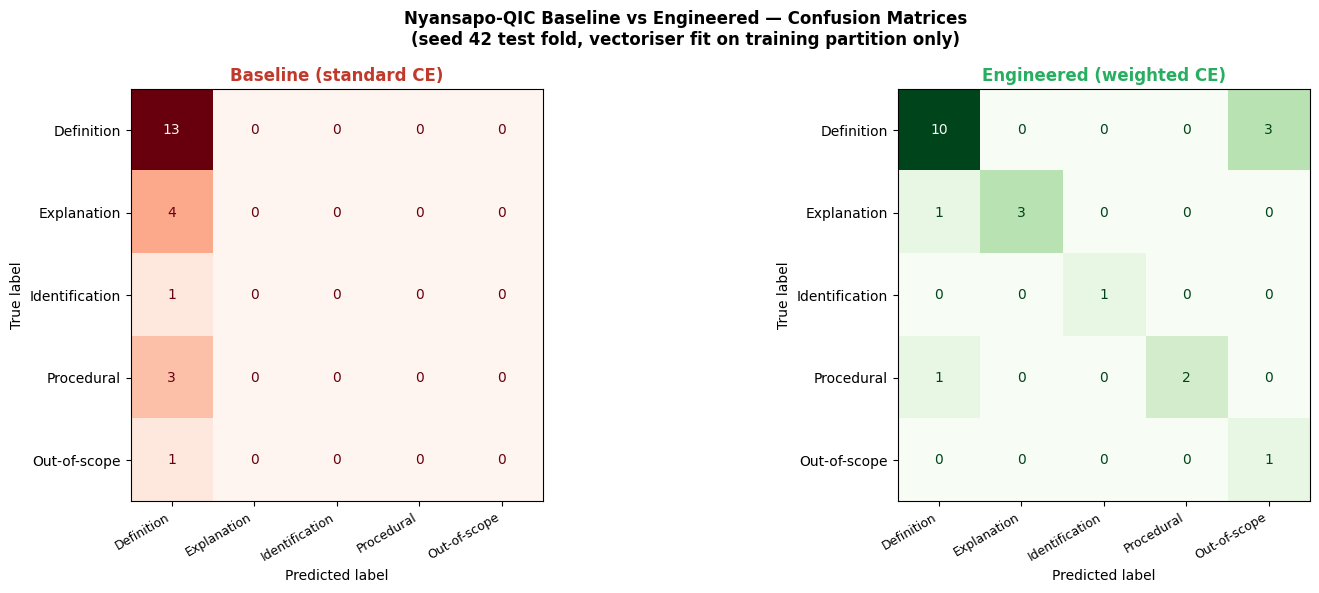

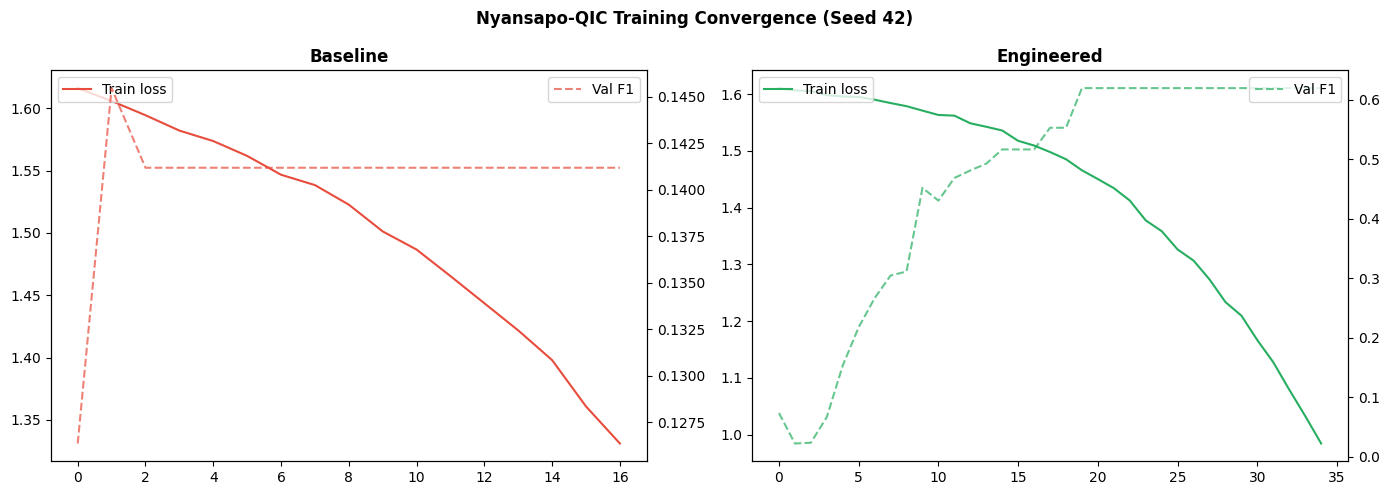

✅ Confusion matrices and convergence curves saved (v3)


In [13]:
base_result = train_model_v2(questions, labels, weight_mode='none', seed=42)
eng_result  = train_model_v2(questions, labels, weight_mode='computed', seed=42)

base_tf1, base_preds, base_y_test, base_losses, base_val_f1s = base_result[:5]
eng_tf1,  eng_preds,  eng_y_test,  eng_losses,  eng_val_f1s  = eng_result[:5]

print("Baseline QIC, seed 42:")
print(classification_report(base_y_test, base_preds, target_names=class_names, zero_division=0))
print(f"Test fold n={len(base_y_test)}")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Nyansapo-QIC Baseline vs Engineered — Confusion Matrices\n'
             '(seed 42 test fold, vectoriser fit on training partition only)',
             fontsize=12, fontweight='bold')
ConfusionMatrixDisplay(confusion_matrix(base_y_test, base_preds), display_labels=class_names).plot(
    ax=axes[0], colorbar=False, cmap='Reds')
axes[0].set_title('Baseline (standard CE)', fontweight='bold', color='#C0392B')
axes[0].set_xticklabels(class_names, rotation=30, ha='right', fontsize=9)
ConfusionMatrixDisplay(confusion_matrix(eng_y_test, eng_preds), display_labels=class_names).plot(
    ax=axes[1], colorbar=False, cmap='Greens')
axes[1].set_title('Engineered (weighted CE)', fontweight='bold', color='#27AE60')
axes[1].set_xticklabels(class_names, rotation=30, ha='right', fontsize=9)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Nyansapo/confusion_matrices_v3.png', dpi=150, bbox_inches='tight')
plt.show()

fig2, axes2 = plt.subplots(1, 2, figsize=(14, 5))
fig2.suptitle('Nyansapo-QIC Training Convergence (Seed 42)', fontsize=12, fontweight='bold')
axes2[0].plot(base_losses, color='#E74C3C', label='Train loss')
ax_t = axes2[0].twinx(); ax_t.plot(base_val_f1s, color='#E74C3C', linestyle='--', alpha=0.7, label='Val F1')
axes2[0].set_title('Baseline', fontweight='bold'); axes2[0].legend(loc='upper left'); ax_t.legend(loc='upper right')
axes2[1].plot(eng_losses, color='#27AE60', label='Train loss')
ax_t2 = axes2[1].twinx(); ax_t2.plot(eng_val_f1s, color='#27AE60', linestyle='--', alpha=0.7, label='Val F1')
axes2[1].set_title('Engineered', fontweight='bold'); axes2[1].legend(loc='upper left'); ax_t2.legend(loc='upper right')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Nyansapo/convergence_v3.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Confusion matrices and convergence curves saved (v3)")

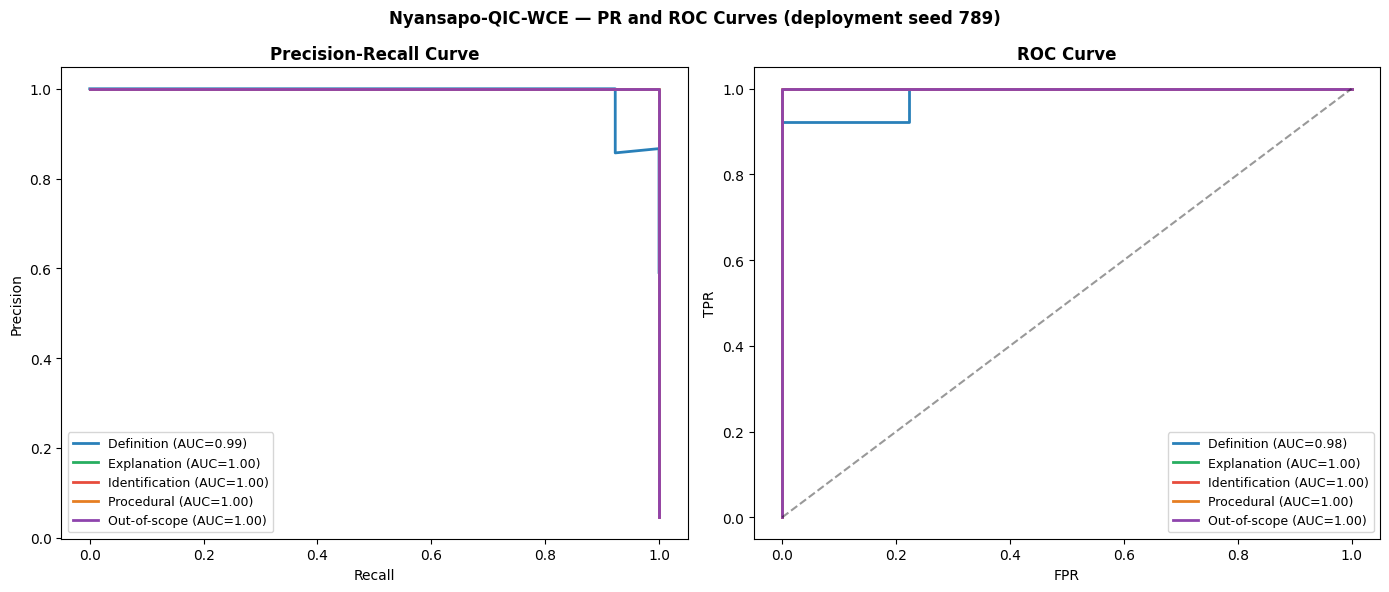

✅ PR/ROC curves saved (v3)


In [14]:
best_res = engineered_runs[best_seed]
tf1_best, preds_best, y_test_best, _, _, vec_best, q_test_best, y_test_arr_best, model_best = best_res

X_test_best = vec_best.transform(q_test_best).toarray().astype(np.float32)
with torch.no_grad():
    probs = torch.softmax(model_best(torch.tensor(X_test_best)), dim=1).numpy()

y_bin = label_binarize(y_test_arr_best, classes=list(range(num_classes)))
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle(f'Nyansapo-QIC-WCE — PR and ROC Curves (deployment seed {best_seed})',
             fontsize=12, fontweight='bold')
colors = ['#2980B9','#27AE60','#E74C3C','#E67E22','#8E44AD']

for i, (name, color) in enumerate(zip(class_names, colors)):
    if y_bin[:, i].sum() == 0: continue
    precision, recall, _ = precision_recall_curve(y_bin[:,i], probs[:,i])
    axes[0].plot(recall, precision, color=color, linewidth=2,
                 label=f'{name} (AUC={auc(recall, precision):.2f})')
axes[0].set_xlabel('Recall'); axes[0].set_ylabel('Precision')
axes[0].set_title('Precision-Recall Curve', fontweight='bold'); axes[0].legend(fontsize=9)

for i, (name, color) in enumerate(zip(class_names, colors)):
    if y_bin[:, i].sum() == 0: continue
    fpr, tpr, _ = roc_curve(y_bin[:,i], probs[:,i])
    axes[1].plot(fpr, tpr, color=color, linewidth=2, label=f'{name} (AUC={auc(fpr,tpr):.2f})')
axes[1].plot([0,1],[0,1],'k--', alpha=0.4)
axes[1].set_xlabel('FPR'); axes[1].set_ylabel('TPR')
axes[1].set_title('ROC Curve', fontweight='bold'); axes[1].legend(fontsize=9)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Nyansapo/pr_roc_v3.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ PR/ROC curves saved (v3)")

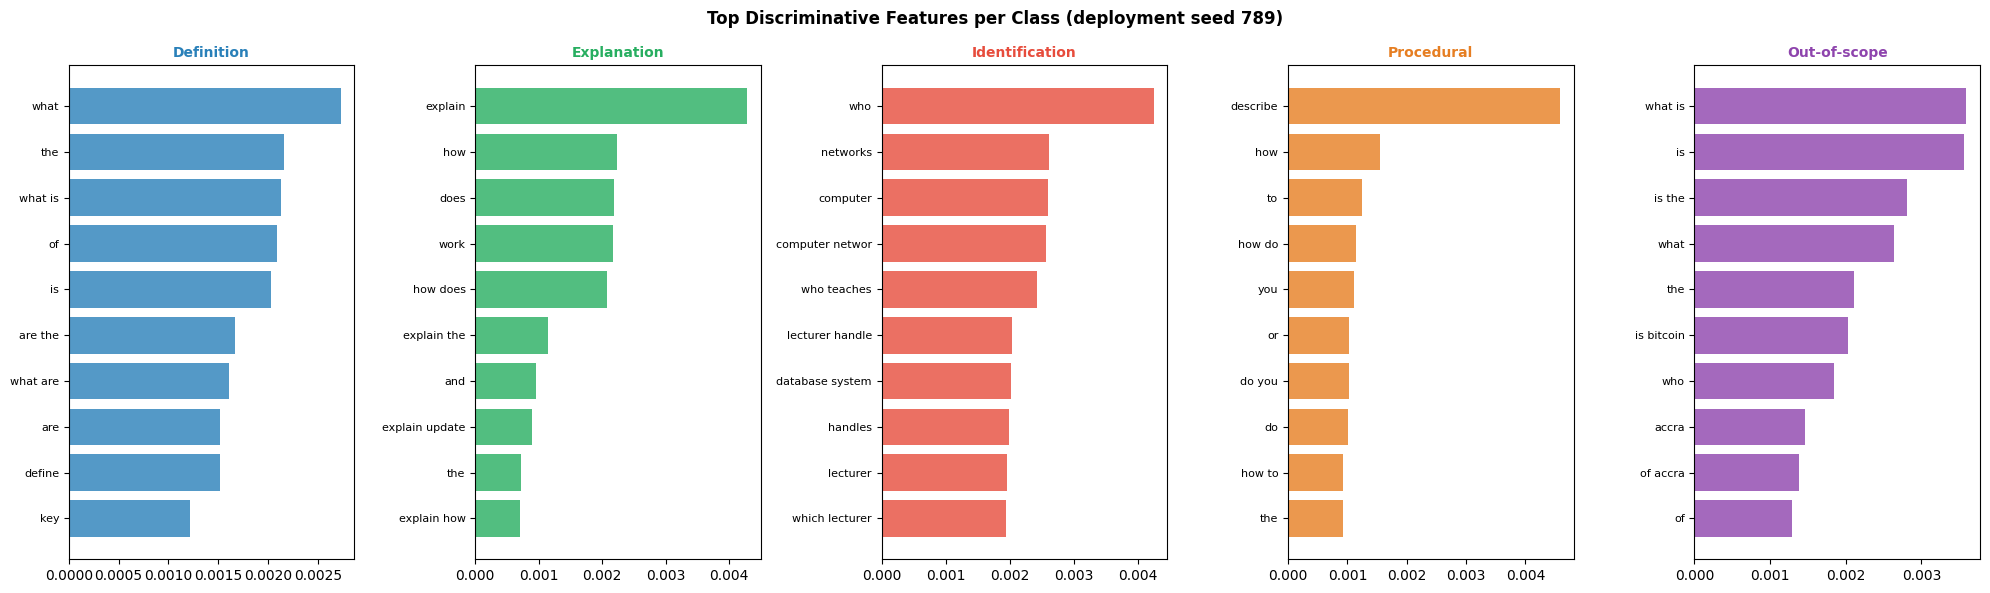

✅ Feature importance saved (v3)


In [15]:
first_layer_weights = model_best.net[0].weight.detach().numpy()
feature_names        = vec_best.get_feature_names_out()
feature_importance   = np.abs(first_layer_weights).mean(axis=0)

q_temp_b, q_test_b, y_temp_b, y_test_b = train_test_split(
    questions, labels, test_size=0.15, stratify=labels, random_state=best_seed)
q_train_b, _, y_train_b, _ = train_test_split(
    q_temp_b, y_temp_b, test_size=0.176, stratify=y_temp_b, random_state=best_seed)
X_train_b = vec_best.transform(q_train_b).toarray().astype(np.float32)
y_train_b = np.array(y_train_b)

fig, axes = plt.subplots(1, 5, figsize=(20, 6))
fig.suptitle(f'Top Discriminative Features per Class (deployment seed {best_seed})',
             fontsize=12, fontweight='bold')
colors_cls = ['#2980B9','#27AE60','#E74C3C','#E67E22','#8E44AD']
for cls_idx, (name, color) in enumerate(zip(class_names, colors_cls)):
    mask = y_train_b == cls_idx
    if mask.sum() == 0:
        axes[cls_idx].set_title(f'{name}\n(no examples)', fontsize=9); continue
    class_mean  = X_train_b[mask].mean(axis=0)
    combined    = class_mean * feature_importance
    top_idx     = np.argsort(combined)[::-1][:10]
    axes[cls_idx].barh(range(10), combined[top_idx][::-1], color=color, alpha=0.8)
    axes[cls_idx].set_yticks(range(10))
    axes[cls_idx].set_yticklabels([feature_names[i][:15] for i in top_idx[::-1]], fontsize=8)
    axes[cls_idx].set_title(name, fontweight='bold', fontsize=10, color=color)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Nyansapo/feature_importance_v3.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Feature importance saved (v3)")

Query count: 22
Original (self-test): F1=0.9526 (should equal 0.9526) — match: True
Paraphrased    : F1=0.7365 (drop: +0.2161)
Ghanaian English: F1=0.7107 (drop: +0.2419)
Typos          : F1=0.7107 (drop: +0.2419)


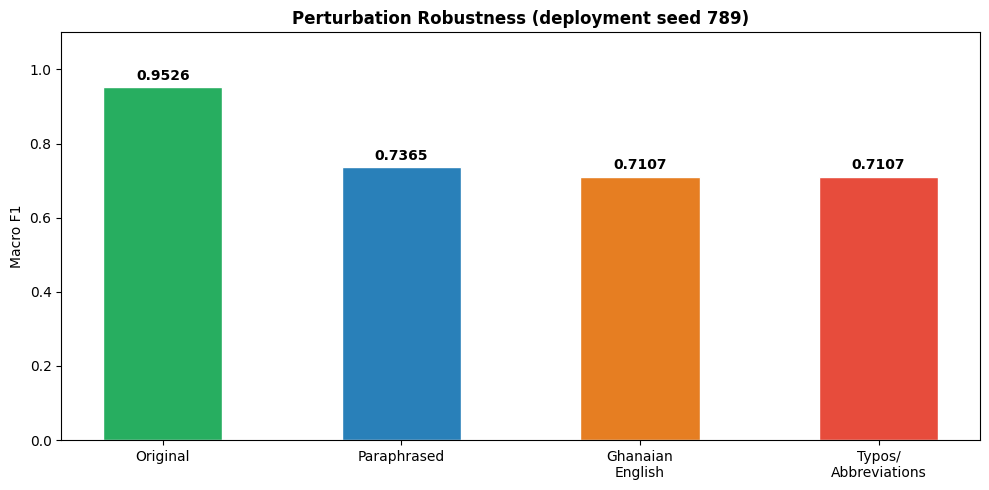

✅ Perturbation analysis saved (v3)


In [16]:
def paraphrase(text):
    reps = {'what is':'define','define':'what is','explain':'describe',
            'describe':'explain','how does':'in what way does',
            'how do':'in what way do','who teaches':'which lecturer teaches',
            'implement':'build','steps':'procedure','what are':'list the',
            'algorithm':'procedure'}
    t = text.lower()
    for old, new in reps.items(): t = t.replace(old, new)
    return t

def ghanaian_english(text):
    prefixes = ["Please I want to know ","Kindly help me understand ",
                "Please what is the meaning of ","I want to ask about "]
    suffixes = [" please"," kindly",", I beg"," pls"]
    r = random.Random(42); q = text.lower()
    return r.choice(prefixes) + q if r.random() > 0.5 else q + r.choice(suffixes)

def add_typos(text):
    abbrevs = {'what':'wat','is':'iz','explain':'xplain','please':'pls',
               'definition':'defn','algorithm':'algo','database':'db',
               'operating system':'os','difference':'diff','between':'btwn'}
    t = text.lower()
    for old, new in abbrevs.items(): t = t.replace(old, new)
    return t

def predict_f1(model, vec, texts, true_labels):
    x = torch.tensor(vec.transform(texts).toarray().astype(np.float32))
    with torch.no_grad():
        preds = model(x).argmax(dim=1).numpy()
    return f1_score(true_labels, preds, average='macro', zero_division=0)

f1_orig  = predict_f1(model_best, vec_best, q_test_best, y_test_arr_best)
f1_para  = predict_f1(model_best, vec_best, [paraphrase(q) for q in q_test_best], y_test_arr_best)
f1_ghana = predict_f1(model_best, vec_best, [ghanaian_english(q) for q in q_test_best], y_test_arr_best)
f1_typo  = predict_f1(model_best, vec_best, [add_typos(q) for q in q_test_best], y_test_arr_best)

print(f"Query count: {len(q_test_best)}")
print(f"Original (self-test): F1={f1_orig:.4f} (should equal {tf1_best:.4f}) — match: {abs(f1_orig-tf1_best)<0.0001}")
print(f"Paraphrased    : F1={f1_para:.4f} (drop: {f1_orig-f1_para:+.4f})")
print(f"Ghanaian English: F1={f1_ghana:.4f} (drop: {f1_orig-f1_ghana:+.4f})")
print(f"Typos          : F1={f1_typo:.4f} (drop: {f1_orig-f1_typo:+.4f})")

fig, ax = plt.subplots(figsize=(10, 5))
conditions = ['Original','Paraphrased','Ghanaian\nEnglish','Typos/\nAbbreviations']
vals = [f1_orig, f1_para, f1_ghana, f1_typo]
bars = ax.bar(conditions, vals, color=['#27AE60','#2980B9','#E67E22','#E74C3C'], edgecolor='white', width=0.5)
ax.set_title(f'Perturbation Robustness (deployment seed {best_seed})', fontweight='bold')
ax.set_ylabel('Macro F1'); ax.set_ylim(0, 1.1)
for bar, v in zip(bars, vals):
    ax.text(bar.get_x()+bar.get_width()/2., bar.get_height()+0.02, f'{v:.4f}', ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Nyansapo/perturbation_v3.png', dpi=150, bbox_inches='tight')
plt.show()

with open('/content/drive/MyDrive/Nyansapo/perturbation_v3.json','w') as f:
    json.dump({"n": len(q_test_best), "original": round(f1_orig,4), "paraphrase": round(f1_para,4),
               "ghanaian": round(f1_ghana,4), "typo": round(f1_typo,4)}, f)
print("✅ Perturbation analysis saved (v3)")

In [18]:
gold = pd.read_csv('/content/drive/MyDrive/Nyansapo/gold_qa_pairs.csv')
gold_questions = gold['question'].tolist()
gold_answers   = gold['gold_answer'].tolist()
print(f"✅ Loaded {len(gold)} gold pairs, courses: {gold['course'].unique()}")

crag_ans, naive_ans, bm25_ans, vanilla_ans = [], [], [], []
for i, q in enumerate(gold_questions):
    chunks, score = crag_retrieve(q, k=5, threshold=0.45)
    crag_ans.append(generate_answer(q, chunks))
    naive_ans.append(generate_answer(q, retrieve(q, k=5)))
    bm25_sc  = bm25.get_scores(q.lower().split())
    bm25_top = np.argsort(bm25_sc)[::-1][:5]
    bm25_ans.append(generate_answer(q, [all_chunks[j] for j in bm25_top if j < len(all_chunks)]))
    prompt = f"Instruct: Answer this question in one sentence.\nQuestion: {q}\nOutput:"
    inputs = tokenizer(prompt, return_tensors="pt", truncation=True, max_length=512).to(model.device)
    with torch.no_grad():
        out = model.generate(**inputs, max_new_tokens=80, do_sample=False,
                            pad_token_id=tokenizer.eos_token_id)
    vanilla_ans.append(tokenizer.decode(out[0][inputs['input_ids'].shape[1]:],
                       skip_special_tokens=True).strip().split('\n')[0])
    if (i+1) % 20 == 0:
        print(f"  {i+1}/{len(gold_questions)} done...")
        with open('/content/drive/MyDrive/Nyansapo/gold_eval_checkpoint_v3.json','w') as f:
            json.dump({"crag":crag_ans,"naive":naive_ans,"bm25":bm25_ans,"vanilla":vanilla_ans,"progress":i+1}, f)

from rouge_score import rouge_scorer as rs
scorer = rs.RougeScorer(['rougeL'], use_stemmer=True)
def rouge_l(cands, refs):
    return np.array([scorer.score(r,c)['rougeL'].fmeasure for c,r in zip(cands, refs)])

crag_r, naive_r, bm25_r, vanilla_r = [rouge_l(a, gold_answers) for a in
    [crag_ans, naive_ans, bm25_ans, vanilla_ans]]

print(f"\nCRAG   : {np.mean(crag_r):.4f} ± {np.std(crag_r):.4f}")
print(f"Naive  : {np.mean(naive_r):.4f} ± {np.std(naive_r):.4f}")
print(f"BM25   : {np.mean(bm25_r):.4f} ± {np.std(bm25_r):.4f}")
print(f"Vanilla: {np.mean(vanilla_r):.4f} ± {np.std(vanilla_r):.4f}")

with open('/content/drive/MyDrive/Nyansapo/gold_rouge_v3.json','w') as f:
    json.dump({"crag":crag_r.tolist(),"naive":naive_r.tolist(),
               "bm25":bm25_r.tolist(),"vanilla":vanilla_r.tolist()}, f)
print("✅ Gold ROUGE-L evaluation saved (v3)")

✅ Loaded 200 gold pairs, courses: ['CSM 478 Computer Networks' 'MCS 472 Fundamentals of Entrepreneurship'
 'Computer Security and Penetration Testing' 'Expert Systems'
 'Introduction to Compilers']
  20/200 done...
  40/200 done...
  60/200 done...
  80/200 done...
  100/200 done...
  120/200 done...
  140/200 done...
  160/200 done...
  180/200 done...
  200/200 done...

CRAG   : 0.2283 ± 0.1410
Naive  : 0.2244 ± 0.1478
BM25   : 0.1733 ± 0.1364
Vanilla: 0.2080 ± 0.0663
✅ Gold ROUGE-L evaluation saved (v3)


In [19]:
from bert_score import score as bert_score_fn
def clean(a): return [x if x and x.strip() else "No answer." for x in a]
def get_bert(cands, refs):
    P, R, F1 = bert_score_fn(clean(cands), refs, lang="en",
                             model_type="distilbert-base-uncased",
                             rescale_with_baseline=False, verbose=False)
    return F1.numpy()

crag_b, naive_b, bm25_b, vanilla_b = [get_bert(a, gold_answers) for a in
    [crag_ans, naive_ans, bm25_ans, vanilla_ans]]

print(f"CRAG   : {np.mean(crag_b):.4f} ± {np.std(crag_b):.4f}")
print(f"Naive  : {np.mean(naive_b):.4f} ± {np.std(naive_b):.4f}")
print(f"BM25   : {np.mean(bm25_b):.4f} ± {np.std(bm25_b):.4f}")
print(f"Vanilla: {np.mean(vanilla_b):.4f} ± {np.std(vanilla_b):.4f}")

for name, a, b in [("CRAG vs Vanilla", crag_r, vanilla_r), ("CRAG vs Naive", crag_r, naive_r), ("CRAG vs BM25", crag_r, bm25_r)]:
    stat, p = stats.wilcoxon(a, b)
    d = (np.mean(a)-np.mean(b)) / np.sqrt((np.std(a)**2+np.std(b)**2)/2)
    print(f"{name} (ROUGE-L): p={p:.6f}, d={d:.4f}")

with open('/content/drive/MyDrive/Nyansapo/gold_bertscore_v3.json','w') as f:
    json.dump({"crag":crag_b.tolist(),"naive":naive_b.tolist(),
               "bm25":bm25_b.tolist(),"vanilla":vanilla_b.tolist()}, f)
print("✅ BERTScore saved (v3)")

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  268MB            

...

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


CRAG   : 0.7897 ± 0.0753
Naive  : 0.7825 ± 0.0973
BM25   : 0.7515 ± 0.0984
Vanilla: 0.7963 ± 0.0318
CRAG vs Vanilla (ROUGE-L): p=0.055630, d=0.1837
CRAG vs Naive (ROUGE-L): p=0.554468, d=0.0264
CRAG vs BM25 (ROUGE-L): p=0.000001, d=0.3959
✅ BERTScore saved (v3)


In [20]:
paired_diff = crag_r - vanilla_r
d = np.mean(paired_diff) / np.std(paired_diff)
alpha = 0.0167
from scipy.stats import norm
z_alpha = norm.ppf(1 - alpha/2)
achieved_power = norm.cdf(abs(d)*np.sqrt(len(paired_diff)) - z_alpha)
n_required = int(np.ceil(((z_alpha + norm.ppf(0.80)) / abs(d))**2))

print(f"n pairs: {len(paired_diff)} | mean delta: {np.mean(paired_diff):.4f} | SD: {np.std(paired_diff):.4f}")
print(f"Cohen's d: {d:.4f} | Achieved power: {achieved_power:.4f} | n required for 80%: {n_required}")
print("Diagnosis:", "POWER DEFICIT — inconclusive" if achieved_power < 0.80 else "Adequate power")

n pairs: 200 | mean delta: 0.0202 | SD: 0.1267
Cohen's d: 0.1596 | Achieved power: 0.4458 | n required for 80%: 411
Diagnosis: POWER DEFICIT — inconclusive


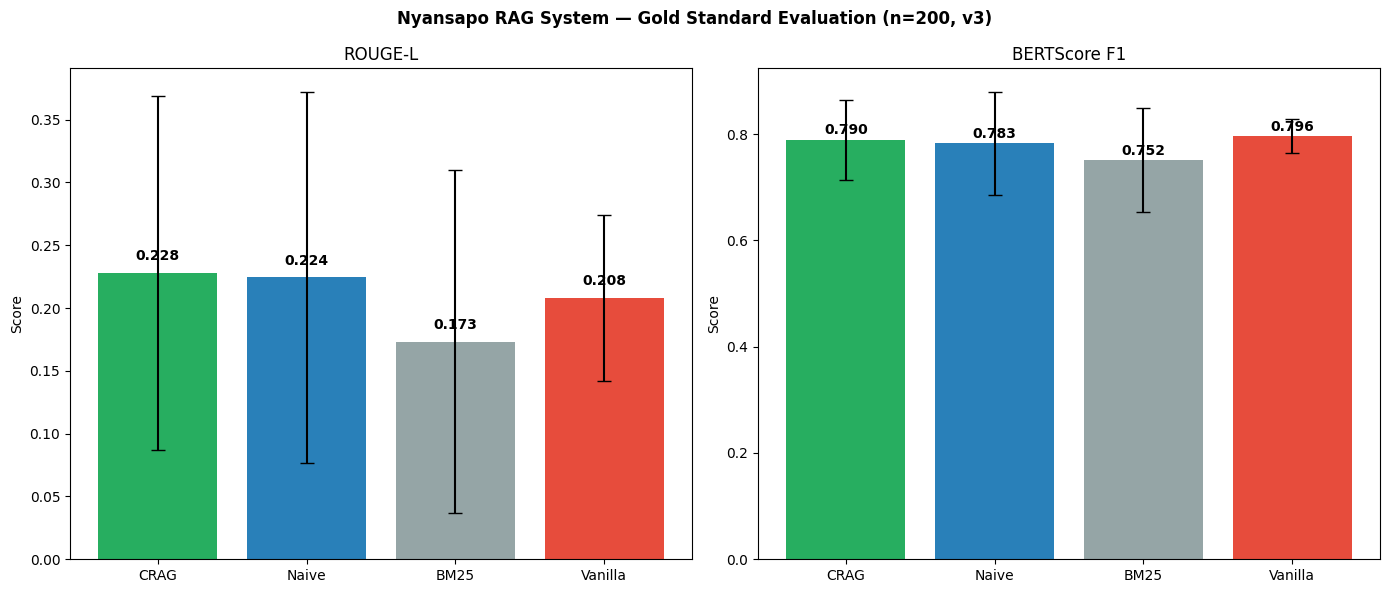

✅ Gold evaluation chart saved (v3)


In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Nyansapo RAG System — Gold Standard Evaluation (n=200, v3)',
             fontsize=12, fontweight='bold')

systems = ['CRAG','Naive','BM25','Vanilla']
colors  = ['#27AE60','#2980B9','#95A5A6','#E74C3C']

rouge_means = [np.mean(crag_r), np.mean(naive_r), np.mean(bm25_r), np.mean(vanilla_r)]
rouge_stds  = [np.std(crag_r),  np.std(naive_r),  np.std(bm25_r),  np.std(vanilla_r)]
bert_means  = [np.mean(crag_b), np.mean(naive_b), np.mean(bm25_b), np.mean(vanilla_b)]
bert_stds   = [np.std(crag_b),  np.std(naive_b),  np.std(bm25_b),  np.std(vanilla_b)]

bars1 = axes[0].bar(systems, rouge_means, color=colors, yerr=rouge_stds, capsize=5)
axes[0].set_title('ROUGE-L'); axes[0].set_ylabel('Score')
for bar, m in zip(bars1, rouge_means):
    axes[0].text(bar.get_x()+bar.get_width()/2., bar.get_height()+0.01, f'{m:.3f}', ha='center', fontweight='bold')

bars2 = axes[1].bar(systems, bert_means, color=colors, yerr=bert_stds, capsize=5)
axes[1].set_title('BERTScore F1'); axes[1].set_ylabel('Score')
for bar, m in zip(bars2, bert_means):
    axes[1].text(bar.get_x()+bar.get_width()/2., bar.get_height()+0.01, f'{m:.3f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Nyansapo/gold_eval_v3.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Gold evaluation chart saved (v3)")

In [ ]:
from scipy import stats as scipy_stats

df = pd.read_csv('data/user_study_anonymized.csv')
df.columns = ['timestamp','consent','year','gender','dept',
              'Q5_trust','Q6_use_exam','Q7_grounded','Q8_recommend',
              'Q9_faster','Q10_source_trust','Q11_understood_intent',
              'Q12_mental_demand','Q13_effort','Q14_frustration','comments']
likert = ['Q5_trust','Q6_use_exam','Q7_grounded','Q8_recommend','Q9_faster',
          'Q10_source_trust','Q11_understood_intent','Q12_mental_demand',
          'Q13_effort','Q14_frustration']
for c in likert: df[c] = pd.to_numeric(df[c], errors='coerce')

df['is_cs'] = df['dept'].str.strip().str.lower().str.contains('computer', na=False)
df['gender_clean'] = df['gender'].str.strip()
trust_cols = likert[:7]; tlx_cols = likert[7:]
df['trust_total'] = df[trust_cols].mean(axis=1)
df['tlx_total']   = df[tlx_cols].mean(axis=1)

print(f"n={len(df)}, CS={df['is_cs'].sum()}, NonCS={(~df['is_cs']).sum()}")
print(f"Male={sum(df['gender_clean']=='Male')}, Female={sum(df['gender_clean']=='Female')}, "
      f"Blank={df['gender_clean'].isna().sum()}")
print(f"Trust: {df['trust_total'].mean():.4f} ± {df['trust_total'].std():.4f}")
print(f"TLX  : {df['tlx_total'].mean():.4f} ± {df['tlx_total'].std():.4f}")

t, p_mid = scipy_stats.ttest_1samp(df['trust_total'].dropna(), 3.0)
print(f"t-test vs midpoint: t={t:.4f}, p={p_mid:.6f}")

cs, ncs = df[df['is_cs']]['trust_total'].dropna(), df[~df['is_cs']]['trust_total'].dropna()
u, p_cs = scipy_stats.mannwhitneyu(cs, ncs)
print(f"CS vs NonCS: CS={cs.mean():.4f}, NonCS={ncs.mean():.4f}, U={u:.1f}, p={p_cs:.6f}")

male, female = df[df['gender_clean']=='Male']['trust_total'].dropna(), df[df['gender_clean']=='Female']['trust_total'].dropna()
u2, p_gender = scipy_stats.mannwhitneyu(male, female)
print(f"Male vs Female: M={male.mean():.4f}, F={female.mean():.4f}, U={u2:.1f}, p={p_gender:.6f}")

with open('/content/drive/MyDrive/Nyansapo/user_study_v3.json','w') as f:
    json.dump({"n":int(len(df)), "trust_mean":round(df['trust_total'].mean(),4),
               "trust_std":round(df['trust_total'].std(),4),
               "tlx_mean":round(df['tlx_total'].mean(),4), "tlx_std":round(df['tlx_total'].std(),4),
               "p_midpoint":round(p_mid,6), "p_cs_noncs":round(p_cs,6), "p_gender":round(p_gender,6)}, f)
print("✅ User trust study saved (v3)")

n=298, CS=219, NonCS=79
Male=152, Female=144, Blank=2
Trust: 4.1795 ± 0.8343
TLX  : 1.8761 ± 0.9051
t-test vs midpoint: t=24.3252, p=0.000000
CS vs NonCS: CS=4.2492, NonCS=3.9814, U=10145.0, p=0.005008
Male vs Female: M=4.2199, F=4.1369, U=11492.5, p=0.430662
✅ User trust study saved (v3)


train=101, val=22, test=22


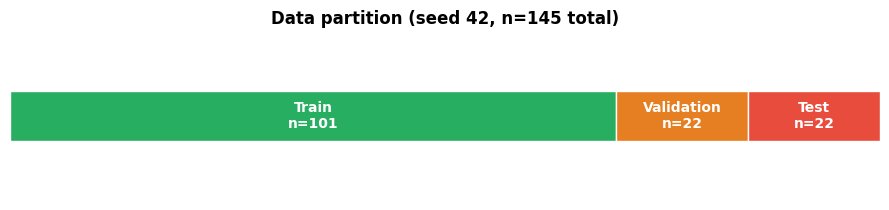

✅ Data partition figure regenerated from actual split code


In [23]:
import matplotlib.pyplot as plt

q_temp, q_test, y_temp, y_test = train_test_split(
    questions, labels, test_size=0.15, stratify=labels, random_state=42)
q_train, q_val, y_train, y_val = train_test_split(
    q_temp, y_temp, test_size=0.176, stratify=y_temp, random_state=42)

n_train, n_val, n_test = len(q_train), len(q_val), len(q_test)
print(f"train={n_train}, val={n_val}, test={n_test}")

fig, ax = plt.subplots(figsize=(9, 2.2))
splits = ['Train', 'Validation', 'Test']
counts = [n_train, n_val, n_test]
colors = ['#27AE60', '#E67E22', '#E74C3C']
left = 0
for s, c, col in zip(splits, counts, colors):
    ax.barh(0, c, left=left, color=col, edgecolor='white', height=0.6)
    ax.text(left + c/2, 0, f'{s}\nn={c}', ha='center', va='center',
             color='white', fontweight='bold', fontsize=10)
    left += c
ax.set_xlim(0, sum(counts))
ax.set_ylim(-1, 1)
ax.axis('off')
ax.set_title(f'Data partition (seed 42, n={sum(counts)} total)', fontweight='bold')
plt.tight_layout()
plt.savefig('data_partition_code_generated.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Data partition figure regenerated from actual split code")

In [ ]:
with open('/content/drive/MyDrive/Nyansapo/qic_vectorizer_v2.pkl', 'rb') as f:
    qic_vectorizer = pickle.load(f)
qic_model = IntentClassifier(500, 256, 5)
qic_model.load_state_dict(torch.load('/content/drive/MyDrive/Nyansapo/qic_wce_model_v2.pt', map_location='cpu'))
qic_model.eval()

def classify_intent(question):
    vec = qic_vectorizer.transform([question]).toarray().astype(np.float32)
    with torch.no_grad():
        logits = qic_model(torch.tensor(vec))
        pred = logits.argmax(dim=1).item()
        conf = torch.softmax(logits, dim=1).max().item()
    return class_names[pred], pred, round(conf, 3)

import nest_asyncio
nest_asyncio.apply()
from fastapi import FastAPI, Request
from fastapi.responses import PlainTextResponse
from fastapi.middleware.cors import CORSMiddleware
from pydantic import BaseModel
import uvicorn
from pyngrok import ngrok
import asyncio
from concurrent.futures import ThreadPoolExecutor

app = FastAPI()
app.add_middleware(CORSMiddleware, allow_origins=["*"], allow_credentials=True,
                   allow_methods=["*"], allow_headers=["*"])
executor = ThreadPoolExecutor(max_workers=1)

class Question(BaseModel):
    question: str

def process_question(question):
    intent, ic, conf = classify_intent(question)
    if ic == 4:
        return {"question": question, "intent": intent, "intent_confidence": conf,
                "answer": "I cannot find this in the lecture materials.",
                "source": "Blocked by Nyansapo-QIC-WCE", "crag_triggered": False}
    chunks, score = crag_retrieve(question, k=5, threshold=0.45)
    answer = generate_answer(question, chunks)
    return {"question": question, "intent": intent, "intent_confidence": conf,
            "answer": answer, "retrieval_score": round(score,3),
            "source": f"Generated from {len(chunks)} chunks", "crag_triggered": score < 0.45}

@app.post("/ask")
async def ask(q: Question):
    loop = asyncio.get_event_loop()
    return await loop.run_in_executor(executor, process_question, q.question)

@app.get("/health")
def health():
    return {"status": "live", "version": "v3", "classifier": "Nyansapo-QIC-WCE",
            "deployment_seed": best_seed, "chunks": index.ntotal}

ngrok.set_auth_token("3EJq3fK62EijdiWESpqBHxvICBv_6otEjkV4QDW4S5YwZZaae")
public_url = ngrok.connect(8000)
print(f"✅ API live: {public_url}/ask")
config = uvicorn.Config(app, host="0.0.0.0", port=8000, loop="asyncio")
server = uvicorn.Server(config)
await server.serve()